In [66]:
from keras.applications import ResNet50,resnet50
from keras.src.legacy.preprocessing.image import ImageDataGenerator
from keras.optimizers import AdamW
from keras.callbacks import EarlyStopping
from keras.layers import Dense
from keras.models import Sequential,save_model
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [52]:
AIRPLANS_IMGS_PATH = '..\\..\\..\\..\\World Of Datasets\\Un-Structured Datasets\\Object Detection\\Natural Images\\airplane'
DRONES_IMGS_PATH = '..\\..\\..\\..\\World Of Datasets\\Un-Structured Datasets\\Object Detection\\Drones Detection Dataset\\drone_dataset\\train\\images'

# Preprocess Input Size
IMG_SIZE = 224

# Build Pre-Trained Params
# WEIGHTS = 'ImageNet'
POOLING = 'avg'
TRAINABLE = False
INCLUDE_TOP = False
NUM_OF_CLASSES = 2
ACTIVATION = 'softmax'

# Flow from dataframe params
BATCH_SIZE = 64
X_COL = 'filename'
Y_COL = 'class'
CLASS_MODE = 'raw'
SEED = 42

# Training Param
EPOCHS = 20

# EarlyStopping Params
PAITENCE = 3
MONITOR = 'val_loss'

# Model Compile Params 
LOSS = 'sparse_categorical_crossentropy'
METRICS = ['accuracy']

# Optimizers Params
LR = 1e-3
WEIGHT_DECAY = 1e-3

# Test size split param
TEST_SIZE = 0.15

#Augs Params:
ROTATION = 45
BRIGHTNESS = [0.8,1.3]
HORIZ_FLIP = True

LABELS = ['Airplane','Drone']

In [ ]:
def prepare_dataset(path):
    drones_items = os.listdir(path)
    all_imgs = []
    all_labels = []
    for item in drones_items:
        img_path = os.path.join(path,item)
        all_imgs.append(img_path)
        all_labels.append(0 if 'airplane' in path else 1)
    
    return (all_imgs,all_labels)

In [ ]:
all_data = prepare_dataset(AIRPLANS_IMGS_PATH)
airplane_df = pd.DataFrame({'filename': all_data[0], 'class': all_data[1]})
airplane_df

,filename,class
0,..\..\..\..\World Of Datasets\Un-Structured Da...,0
1,..\..\..\..\World Of Datasets\Un-Structured Da...,0
2,..\..\..\..\World Of Datasets\Un-Structured Da...,0
3,..\..\..\..\World Of Datasets\Un-Structured Da...,0
4,..\..\..\..\World Of Datasets\Un-Structured Da...,0
...,...,...
722,..\..\..\..\World Of Datasets\Un-Structured Da...,0
723,..\..\..\..\World Of Datasets\Un-Structured Da...,0
724,..\..\..\..\World Of Datasets\Un-Structured Da...,0
725,..\..\..\..\World Of Datasets\Un-Structured Da...,0


In [18]:
all_data = prepare_dataset(DRONES_IMGS_PATH)
drone_df = pd.DataFrame({'filename': all_data[0], 'class': all_data[1]})
drone_df

,filename,class
0,..\..\..\..\World Of Datasets\Un-Structured Da...,1
1,..\..\..\..\World Of Datasets\Un-Structured Da...,1
2,..\..\..\..\World Of Datasets\Un-Structured Da...,1
3,..\..\..\..\World Of Datasets\Un-Structured Da...,1
4,..\..\..\..\World Of Datasets\Un-Structured Da...,1
...,...,...
1007,..\..\..\..\World Of Datasets\Un-Structured Da...,1
1008,..\..\..\..\World Of Datasets\Un-Structured Da...,1
1009,..\..\..\..\World Of Datasets\Un-Structured Da...,1
1010,..\..\..\..\World Of Datasets\Un-Structured Da...,1


In [19]:
df = pd.concat([airplane_df,drone_df],axis=0)
df

,filename,class
0,..\..\..\..\World Of Datasets\Un-Structured Da...,0
1,..\..\..\..\World Of Datasets\Un-Structured Da...,0
2,..\..\..\..\World Of Datasets\Un-Structured Da...,0
3,..\..\..\..\World Of Datasets\Un-Structured Da...,0
4,..\..\..\..\World Of Datasets\Un-Structured Da...,0
...,...,...
1007,..\..\..\..\World Of Datasets\Un-Structured Da...,1
1008,..\..\..\..\World Of Datasets\Un-Structured Da...,1
1009,..\..\..\..\World Of Datasets\Un-Structured Da...,1
1010,..\..\..\..\World Of Datasets\Un-Structured Da...,1


In [ ]:
train,test = train_test_split(df,test_size=TEST_SIZE,stratify=df['class'],random_state=SEED)
train , valid = train_test_split(train,test_size=TEST_SIZE,stratify=train['class'],random_state=SEED)

,filename,class
264,..\..\..\..\World Of Datasets\Un-Structured Da...,1
781,..\..\..\..\World Of Datasets\Un-Structured Da...,1
873,..\..\..\..\World Of Datasets\Un-Structured Da...,1
467,..\..\..\..\World Of Datasets\Un-Structured Da...,1
185,..\..\..\..\World Of Datasets\Un-Structured Da...,0
...,...,...
925,..\..\..\..\World Of Datasets\Un-Structured Da...,1
778,..\..\..\..\World Of Datasets\Un-Structured Da...,1
250,..\..\..\..\World Of Datasets\Un-Structured Da...,1
181,..\..\..\..\World Of Datasets\Un-Structured Da...,1


In [30]:
train['class'].value_counts()

class
1    731
0    525
Name: count, dtype: int64

In [31]:
valid['class'].value_counts()

class
1    129
0     93
Name: count, dtype: int64

In [32]:
test['class'].value_counts()

class
1    152
0    109
Name: count, dtype: int64

In [33]:
train

,filename,class
264,..\..\..\..\World Of Datasets\Un-Structured Da...,1
781,..\..\..\..\World Of Datasets\Un-Structured Da...,1
873,..\..\..\..\World Of Datasets\Un-Structured Da...,1
467,..\..\..\..\World Of Datasets\Un-Structured Da...,1
185,..\..\..\..\World Of Datasets\Un-Structured Da...,0
...,...,...
925,..\..\..\..\World Of Datasets\Un-Structured Da...,1
778,..\..\..\..\World Of Datasets\Un-Structured Da...,1
250,..\..\..\..\World Of Datasets\Un-Structured Da...,1
181,..\..\..\..\World Of Datasets\Un-Structured Da...,1


In [34]:
valid

,filename,class
570,..\..\..\..\World Of Datasets\Un-Structured Da...,0
998,..\..\..\..\World Of Datasets\Un-Structured Da...,1
538,..\..\..\..\World Of Datasets\Un-Structured Da...,0
552,..\..\..\..\World Of Datasets\Un-Structured Da...,1
597,..\..\..\..\World Of Datasets\Un-Structured Da...,1
...,...,...
373,..\..\..\..\World Of Datasets\Un-Structured Da...,0
186,..\..\..\..\World Of Datasets\Un-Structured Da...,0
176,..\..\..\..\World Of Datasets\Un-Structured Da...,0
83,..\..\..\..\World Of Datasets\Un-Structured Da...,0


In [35]:
test

,filename,class
273,..\..\..\..\World Of Datasets\Un-Structured Da...,0
256,..\..\..\..\World Of Datasets\Un-Structured Da...,1
762,..\..\..\..\World Of Datasets\Un-Structured Da...,1
706,..\..\..\..\World Of Datasets\Un-Structured Da...,0
156,..\..\..\..\World Of Datasets\Un-Structured Da...,0
...,...,...
784,..\..\..\..\World Of Datasets\Un-Structured Da...,1
600,..\..\..\..\World Of Datasets\Un-Structured Da...,0
520,..\..\..\..\World Of Datasets\Un-Structured Da...,0
389,..\..\..\..\World Of Datasets\Un-Structured Da...,0


In [56]:
train_gen = ImageDataGenerator(preprocessing_function=resnet50.preprocess_input,rotation_range=ROTATION,horizontal_flip=HORIZ_FLIP,brightness_range=BRIGHTNESS)

valid_gen = ImageDataGenerator(preprocessing_function=resnet50.preprocess_input)

test_gen = ImageDataGenerator(preprocessing_function=resnet50.preprocess_input)

In [57]:
train_data = train_gen.flow_from_dataframe(train,
                                           x_col=X_COL,
                                           y_col=Y_COL,
                                           target_size=(IMG_SIZE,IMG_SIZE),
                                           batch_size=BATCH_SIZE,
                                           shuffle=True,
                                           class_mode=CLASS_MODE,
                                           seed=SEED)


valid_data = valid_gen.flow_from_dataframe(valid,
                                           x_col=X_COL,
                                           y_col=Y_COL,
                                           target_size=(IMG_SIZE,IMG_SIZE),
                                           batch_size=16,
                                           shuffle=False,
                                           class_mode=CLASS_MODE,
                                           )

test_data = test_gen.flow_from_dataframe(test,
                                          x_col=X_COL,
                                          target_size=(IMG_SIZE,IMG_SIZE),
                                          batch_size=1,
                                          shuffle=False,
                                          class_mode=CLASS_MODE,
                                          )

Found 1256 validated image filenames.
Found 222 validated image filenames.
Found 261 validated image filenames.


In [58]:
drone_classifier = Sequential([ResNet50(include_top=INCLUDE_TOP,pooling=POOLING),
                               Dense(NUM_OF_CLASSES,activation=ACTIVATION)])

drone_classifier.layers[0].trainable = TRAINABLE

In [59]:
optimizer = AdamW(learning_rate=LR,weight_decay=WEIGHT_DECAY)

callbacks = [EarlyStopping(monitor=MONITOR,patience=PAITENCE,restore_best_weights=True)]

In [60]:
drone_classifier.compile(optimizer=optimizer,loss=LOSS,metrics=METRICS)

drone_classifier.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │         4,098 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [61]:
history = drone_classifier.fit(train_data,
                     validation_data=valid_data,
                     epochs=EPOCHS,
                     verbose=1,
                     callbacks=callbacks)

Epoch 1/20


c:\Python313\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


20/20 ━━━━━━━━━━━━━━━━━━━━ 68s 3s/step - accuracy: 0.8933 - loss: 0.2399 - val_accuracy: 0.9955 - val_loss: 0.0352
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step - accuracy: 0.9984 - loss: 0.0196 - val_accuracy: 1.0000 - val_loss: 0.0102
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 60s 3s/step - accuracy: 0.9992 - loss: 0.0131 - val_accuracy: 1.0000 - val_loss: 0.0067
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step - accuracy: 0.9992 - loss: 0.0079 - val_accuracy: 1.0000 - val_loss: 0.0055
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 60s 3s/step - accuracy: 0.9992 - loss: 0.0080 - val_accuracy: 1.0000 - val_loss: 0.0046
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 1.0000 - loss: 0.0057 - val_accuracy: 1.0000 - val_loss: 0.0040
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.9992 - loss: 0.0057 - val_accuracy: 1.0000 - val_loss: 0.0035
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.9992 - loss: 0.0050 - val_accuracy: 1.0000 - val_loss: 0.0030
Epo

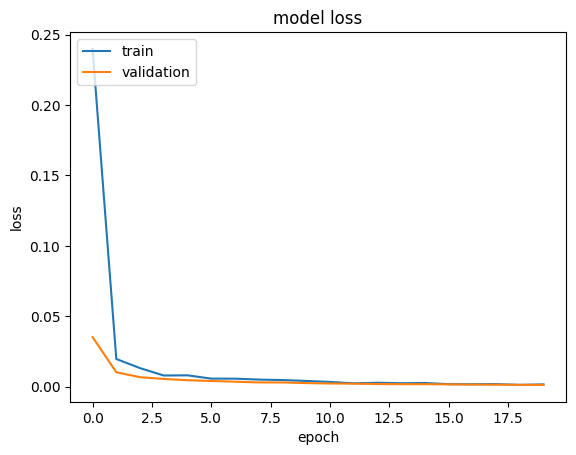

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

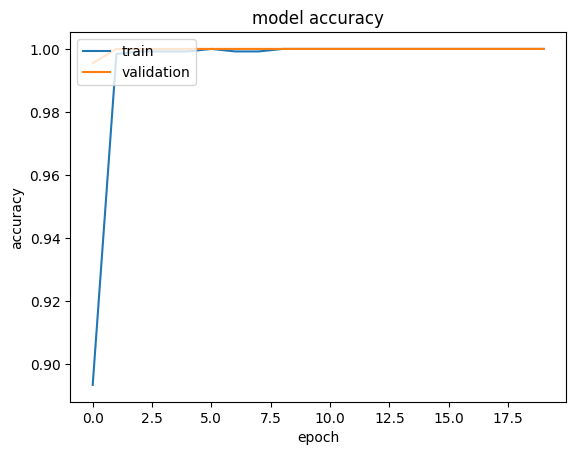

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [ ]:
test_data.reset()
y_pred = drone_classifier.predict(test_data)
final_y_pred = np.argmax(y_pred, axis=1)

 76/261 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step

c:\Python313\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


261/261 ━━━━━━━━━━━━━━━━━━━━ 16s 55ms/step


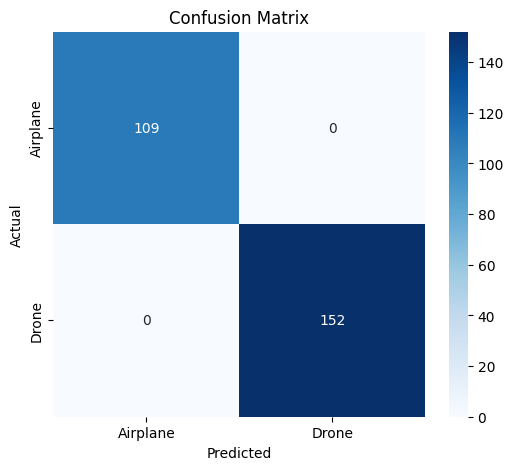

In [67]:
y_true = test['class'].values
cm = confusion_matrix(y_true, final_y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=LABELS, yticklabels=LABELS)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

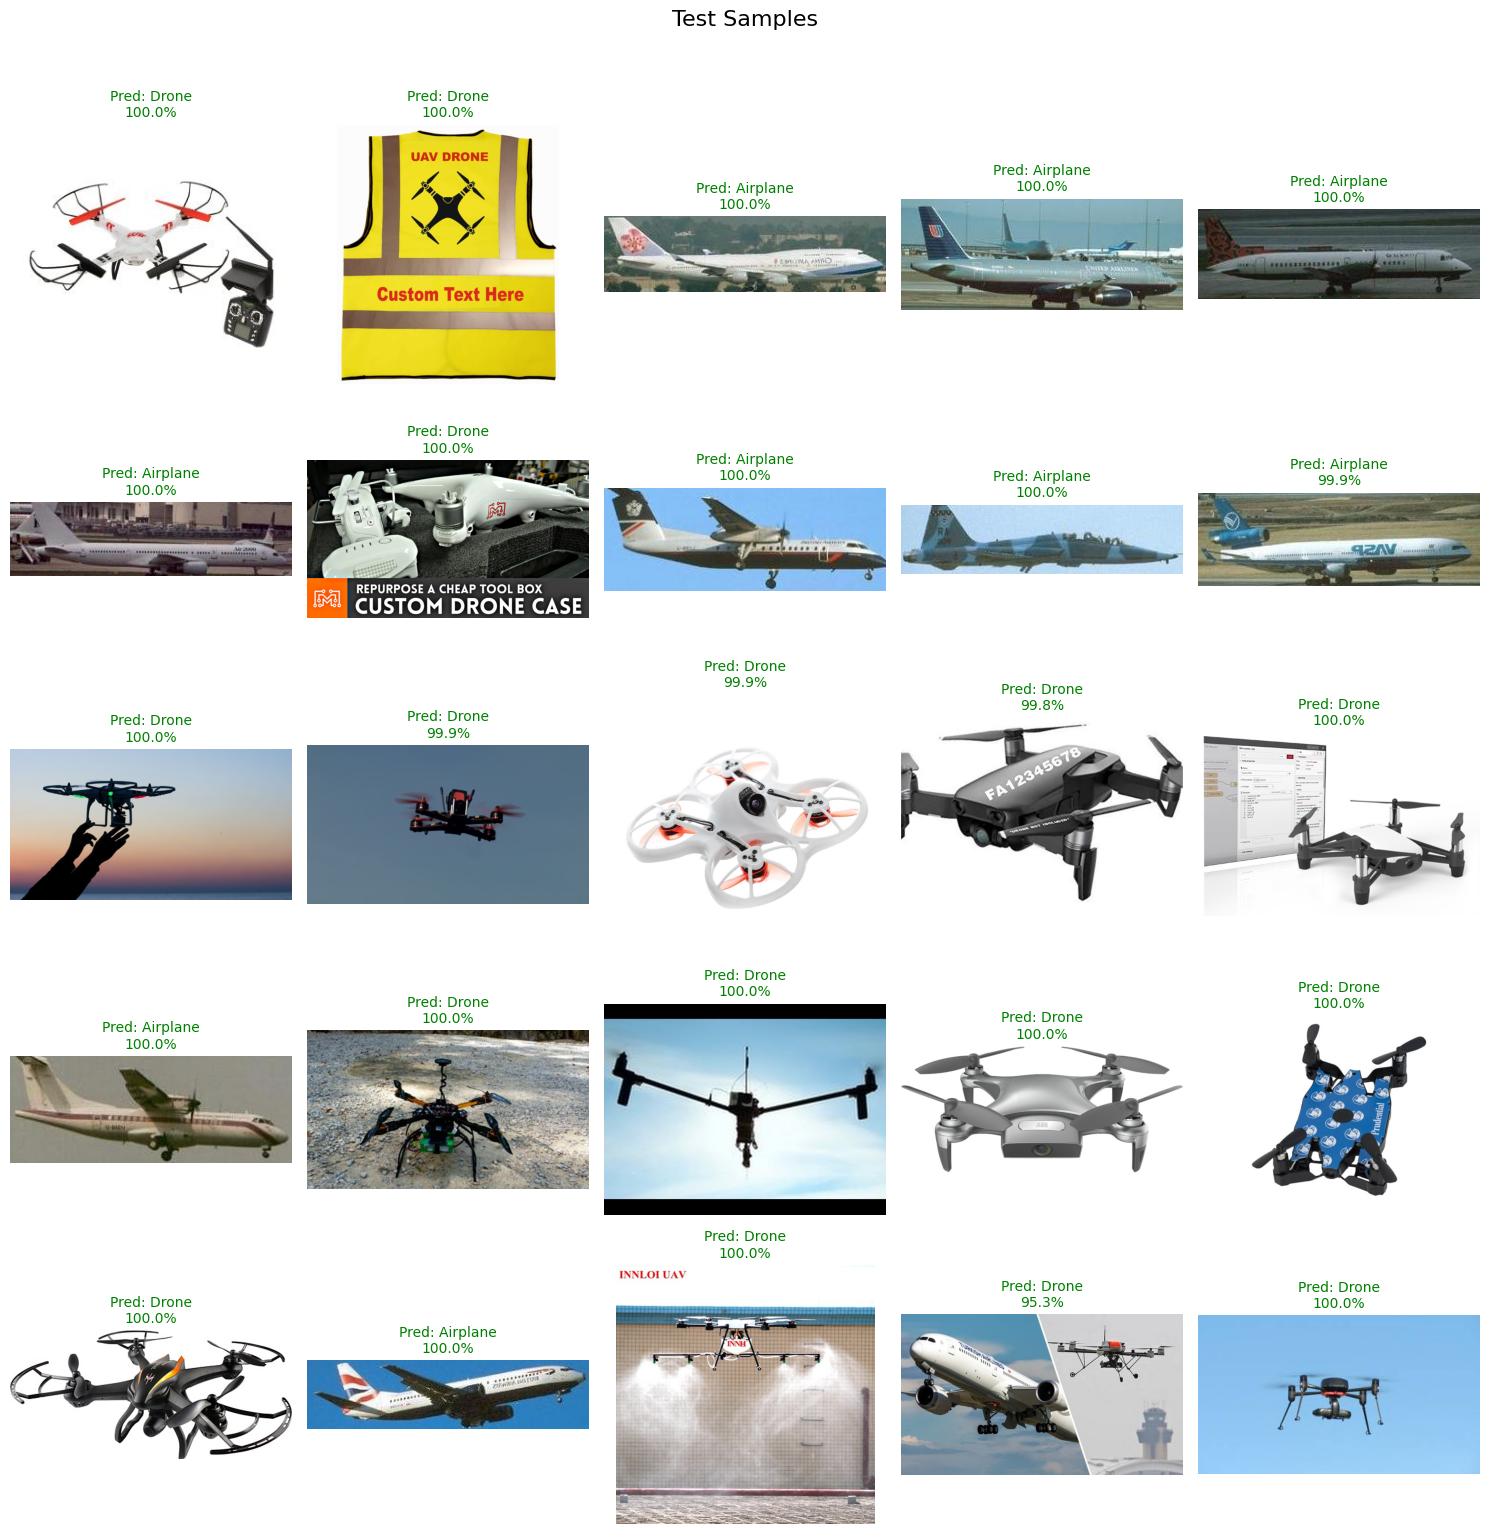

In [70]:
f, ax = plt.subplots(5, 5, figsize=(15, 15))
f.suptitle('Test Samples', fontsize=16, y=1.02)
for i, idx in enumerate(np.random.randint(len(test_data.filenames), size=25)):
    img = plt.imread(test_data.filenames[idx])
    
    predicted_class = LABELS[final_y_pred[idx]]
    confidence = np.max(y_pred[idx]) * 100
    color = 'green' if predicted_class == LABELS[int(test.iloc[idx]['class'])] else 'red'
    
    ax[i//5, i%5].imshow(img)
    ax[i//5, i%5].axis('off')
    ax[i//5, i%5].set_title(f"Pred: {predicted_class}\n{confidence:.1f}%", fontsize=10, color=color)
plt.tight_layout()
plt.show()

In [74]:
save_model(drone_classifier,'drone_classifier_model.keras')